In [35]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline

In [36]:
df= pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


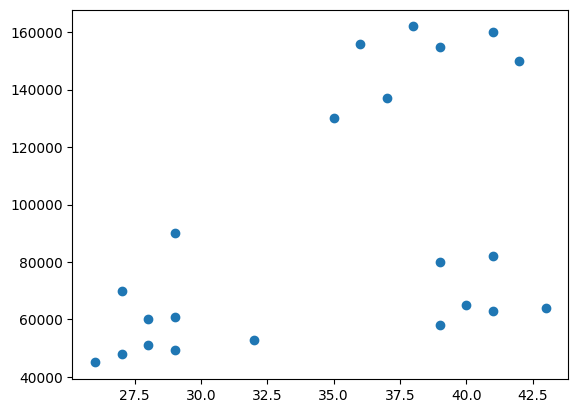

In [37]:
plt.scatter(df["Age"], df["Income($)"])

In [38]:
km= KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [39]:
y_predicted= km.fit_predict(df[["Age", "Income($)"]])
y_predicted

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [44]:
df["cluter"]= y_predicted
df.head()

,Name,Age,Income($),cluter
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


C:\Users\Niloy\AppData\Local\Temp\ipykernel_2292\212135516.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


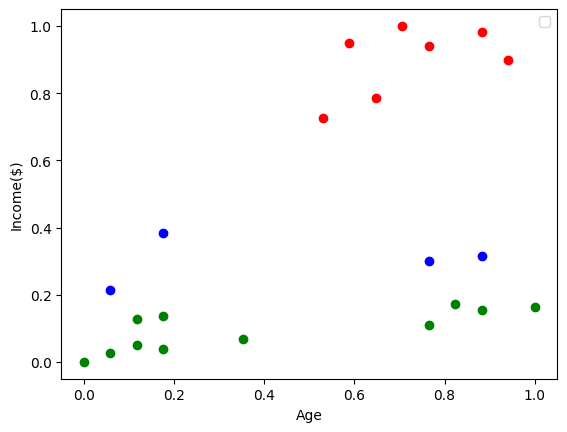

In [46]:
df1= df[df.cluter==0]
df2= df[df.cluter==1]
df3= df[df.cluter==2]
plt.scatter(df1["Age"], df1["Income($)"], color="green")
plt.scatter(df2["Age"], df2["Income($)"], color="red")
plt.scatter(df3["Age"], df3["Income($)"], color="blue")
plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()

In [47]:
scaler = MinMaxScaler()

scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])
df.head()

,Name,Age,Income($),cluter
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


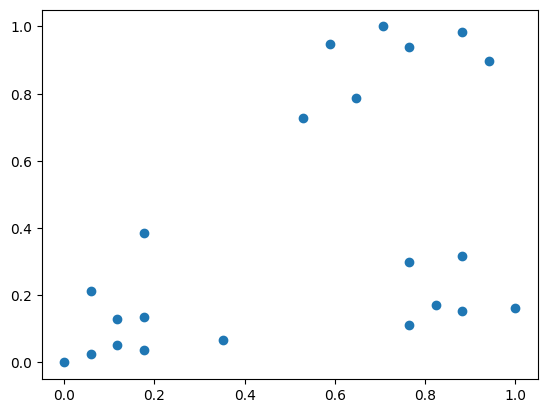

In [48]:
plt.scatter(df.Age,df['Income($)'])

In [50]:
km1= KMeans(n_clusters=3)
y_predicted1= km1.fit_predict(df[["Age", "Income($)"]])
y_predicted1

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [51]:
df["Cluster"]= y_predicted1

df

,Name,Age,Income($),cluter,Cluster
0,Rob,0.058824,0.213675,2,1
1,Michael,0.176471,0.384615,2,1
2,Mohan,0.176471,0.136752,0,1
3,Ismail,0.117647,0.128205,0,1
4,Kory,0.941176,0.897436,1,0
5,Gautam,0.764706,0.940171,1,0
6,David,0.882353,0.982906,1,0
7,Andrea,0.705882,1.000000,1,0
8,Brad,0.588235,0.948718,1,0
9,Angelina,0.529412,0.726496,1,0


C:\Users\Niloy\AppData\Local\Temp\ipykernel_2292\2424790544.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


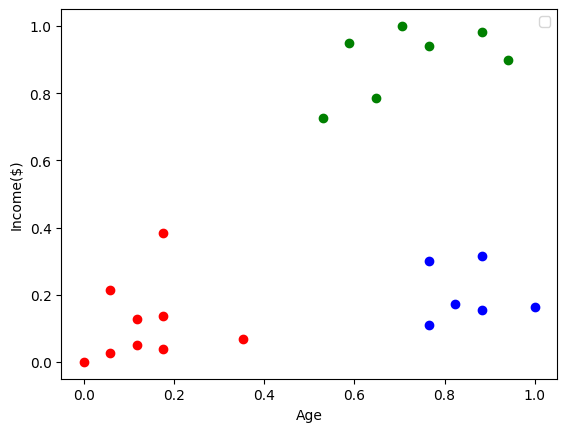

In [52]:
df4= df[df.Cluster==0]
df5= df[df.Cluster==1]
df6= df[df.Cluster==2]
plt.scatter(df4["Age"], df4["Income($)"], color="green")
plt.scatter(df5["Age"], df5["Income($)"], color="red")
plt.scatter(df6["Age"], df6["Income($)"], color="blue")
plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()


In [53]:
sse= []
k_rng= range(1, 10)
for k in k_rng:
    km= KMeans(n_clusters=k)
    km.fit(df[["Age", "Income($)"]])
    sse.append(km.inertia_)

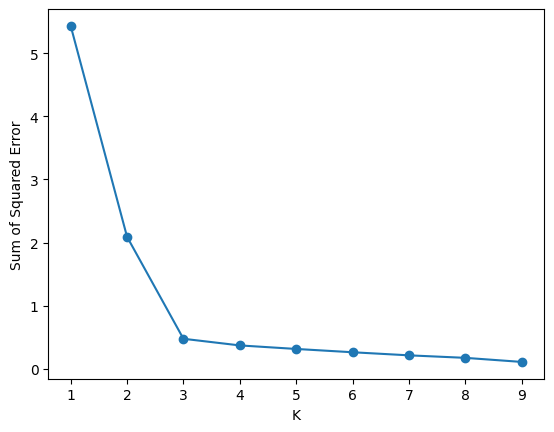

In [54]:
plt.xlabel("K")
plt.ylabel("Sum of Squared Error")
plt.plot(k_rng, sse, marker='o')